# Aula 05 — PSO (Particle Swarm Optimization)

Este notebook resolve as quatro missões do roteiro. As sementes aleatórias são fixas para que os resultados sejam reproduzíveis. A função de custo logístico é mantida positiva e minimizada, de acordo com o objetivo do enunciado.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from solucao_aula05 import missao_1, missao_2, missao_3, missao_4


## Missão 1 — A partícula solitária

Objetivo: completar a atualização de velocidade e posição para minimizar `f(x) = x²`.

Posição inicial: 6.100058
Fitness inicial: 37.210713
Melhor posição: 3.239543
Melhor fitness: 10.494642
Melhor iteração: 20
Encontrou o mínimo (f <= 1e-4): False


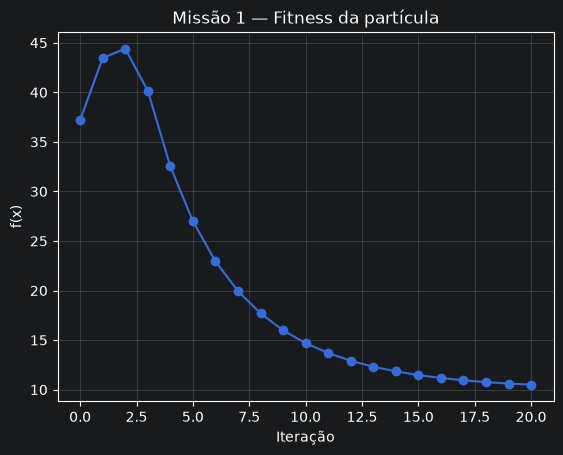

In [2]:
m1 = missao_1()
print(f"Posição inicial: {m1['posicao_inicial']:.6f}")
print(f"Fitness inicial: {m1['fitness_inicial']:.6f}")
print(f"Melhor posição: {m1['pbest_pos']:.6f}")
print(f"Melhor fitness: {m1['pbest_fit']:.6f}")
print(f"Melhor iteração: {m1['melhor_iteracao']}")
print(f"Encontrou o mínimo (f <= 1e-4): {m1['encontrou_minimo']}")

plt.plot(m1['historico_fit'], marker='o')
plt.title('Missão 1 — Fitness da partícula')
plt.xlabel('Iteração')
plt.ylabel('f(x)')
plt.grid(alpha=0.3)
plt.show()


## Missão 2 — O enxame

Objetivo: aplicar o PSO à função de Rosenbrock, cujo mínimo global é `(1, 1)`.

Melhor posição: (1.130272, 1.278378)
Melhor fitness: 0.017045
Melhor iteração: 45
Encontrou o mínimo (f <= 1e-2): False


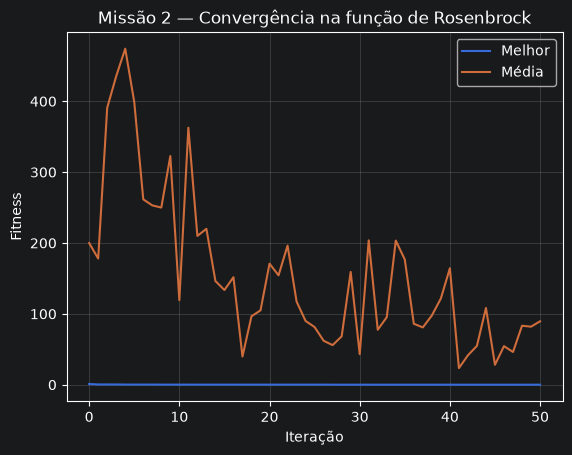

In [3]:
m2 = missao_2()
print(f"Melhor posição: ({m2['gbest_pos'][0]:.6f}, {m2['gbest_pos'][1]:.6f})")
print(f"Melhor fitness: {m2['gbest_fit']:.6f}")
print(f"Melhor iteração: {m2['melhor_iteracao']}")
print(f"Encontrou o mínimo (f <= 1e-2): {m2['encontrou_minimo']}")

plt.plot(m2['historico_melhor'], label='Melhor')
plt.plot(m2['historico_media'], label='Média')
plt.title('Missão 2 — Convergência na função de Rosenbrock')
plt.xlabel('Iteração')
plt.ylabel('Fitness')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Missão 3 — Otimização logística

Objetivo: localizar cinco centros para atender cinquenta clientes, minimizando a soma de `distância × demanda`.

Custo inicial: 4611.84
Custo final: 3233.68
Melhoria: 29.88%
Centro 1: (1.3082, 4.4986)
Centro 2: (2.2546, 6.7216)
Centro 3: (7.5569, 7.7285)
Centro 4: (4.4345, 2.2698)
Centro 5: (7.6503, 2.6497)


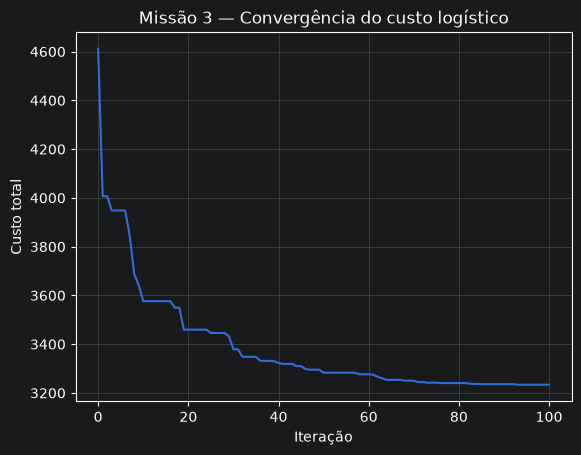

In [4]:
m3 = missao_3()
melhoria = 100 * (1 - m3['gbest_fit'] / m3['custo_inicial'])
print(f"Custo inicial: {m3['custo_inicial']:.2f}")
print(f"Custo final: {m3['gbest_fit']:.2f}")
print(f"Melhoria: {melhoria:.2f}%")
for i, centro in enumerate(m3['centros'], start=1):
    print(f"Centro {i}: ({centro[0]:.4f}, {centro[1]:.4f})")

plt.plot(m3['historico'])
plt.title('Missão 3 — Convergência do custo logístico')
plt.xlabel('Iteração')
plt.ylabel('Custo total')
plt.grid(alpha=0.3)
plt.show()


## Missão 4 — Otimização dos parâmetros

Cada configuração é executada cinco vezes. A comparação usa o custo médio; quanto menor, melhor.

In [5]:
m4 = missao_4()
for nome, resultado in m4['resultados'].items():
    print(
        f"{nome}: médio={resultado['custo_medio']:.2f} ± {resultado['custo_std']:.2f}; "
        f"melhor={resultado['melhor_custo']:.2f}; pior={resultado['pior_custo']:.2f}"
    )
print(f"\nMelhor configuração: {m4['melhor_configuracao']}")
print(f"Pior configuração: {m4['pior_configuracao']}")


Padrão: médio=3367.20 ± 82.08; melhor=3269.36; pior=3464.72
Inércia Alta: médio=3645.00 ± 92.87; melhor=3532.41; pior=3809.79
Inércia Baixa: médio=3349.66 ± 125.69; melhor=3233.46; pior=3567.22
Cognitivo Alto: médio=3482.60 ± 46.61; melhor=3398.63; pior=3538.34
Social Alto: médio=3646.57 ± 150.30; melhor=3411.28; pior=3850.84
Mais Partículas: médio=3322.06 ± 46.59; melhor=3257.98; pior=3375.81

Melhor configuração: Mais Partículas
Pior configuração: Social Alto


## Conclusões para o relatório

- `pBest` é a melhor posição já encontrada por uma partícula; `gBest` é a melhor posição encontrada pelo enxame.
- Na Missão 1, uma única partícula não recebe atração cognitiva/social efetiva, pois `pBest` e `gBest` começam na posição atual.
- Na Missão 2, o enxame se aproxima do mínimo global de Rosenbrock.
- Na Missão 3, os centros são avaliados pelo custo ponderado pela demanda.
- Na Missão 4, mais partículas obtiveram o menor custo médio nesta execução; os resultados dependem da semente aleatória.